# 원자료 → 전처리 → Figure 1

**모든 셀을 순서대로 실행하세요.** 입력은 `data/herbal/`의 CSV 5개와 `data/recipe1m/`의 파일 2개입니다. 기존 `work/`나 `figures/`의 결과를 읽지 않고, 빈 작업 폴더에서 새로 계산합니다. 아래 출력은 실행 결과이며 집계 수치를 코드에 고정하지 않았습니다.

전처리 구현은 [run.py](https://github.com/inseong101/HerbalFormulaCompletion/blob/main/run.py)에 있습니다. 범위는 전처리와 Figure 1까지이며, 후속 모델 학습·평가는 포함하지 않습니다.


## 1. 코드와 원자료 준비
Colab에서는 코드를 복제하고 GitHub에 저장된 원자료를 HTTPS로 내려받아 SHA-256을 검증합니다. Git LFS 설치나 전역 Git 설정은 필요하지 않습니다. 로컬에서는 이 저장소 폴더에서 실행합니다. 오류가 발생하면 다음 단계로 진행하지 않습니다.


In [ ]:
from pathlib import Path
import csv, hashlib, importlib.util, json, os, shutil, subprocess, sys, tempfile
from collections import Counter
from urllib.request import urlopen
from IPython.display import Image, display

IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib>=3.9,<4", "tqdm>=4.66,<5"], check=True)
    repo = Path(tempfile.mkdtemp(prefix="hfc-source-")) / "repository"
    # Disable LFS filters: clone code and pointers without configuring Git globally.
    subprocess.run(["git", "-c", "filter.lfs.required=false", "-c", "filter.lfs.smudge=", "-c", "filter.lfs.process=", "clone", "https://github.com/inseong101/HerbalFormulaCompletion.git", str(repo)], env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"}, check=True)
    commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=repo, text=True).strip()
    # Fetch the actual LFS objects over HTTPS; no git-lfs installation is needed.
    for name, expected in [
        ("det_ingrs.json", "e1399c338b004f83f3dd9d85a8479dd04f120666e35f4d67c4b6947fae07aa50"),
        ("recipe1M_layers.tar.gz", "e180260dcd438be96e63c1c68b5f09a6415d1d1c51b1f2c2bc0b08079cb5d6c3"),
    ]:
        destination = repo / "data/recipe1m" / name
        temporary = destination.with_name(name + ".download")
        url = f"https://media.githubusercontent.com/media/inseong101/HerbalFormulaCompletion/{commit}/data/recipe1m/{name}"
        print("Downloading:", name, flush=True)
        with urlopen(url, timeout=120) as response, temporary.open("wb") as handle:
            shutil.copyfileobj(response, handle, length=1024 * 1024)
        with temporary.open("rb") as handle:
            actual = hashlib.file_digest(handle, "sha256").hexdigest()
        if actual != expected:
            temporary.unlink()
            raise ValueError(f"Source checksum mismatch: {name}. Download rejected.")
        temporary.replace(destination)
        print("Verified:", name, destination.stat().st_size, "bytes", flush=True)
else:
    repo = Path.cwd()
    assert (repo / "run.py").is_file(), "Run this notebook in the repository directory."
print("Code commit:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=repo, text=True).strip())
import matplotlib
print("Python:", sys.version.split()[0], "Matplotlib:", matplotlib.__version__)


## 2. 입력 파일 확인 및 빈 작업 폴더 생성
파일 크기와 SHA-256을 기록합니다. 새 작업 폴더에는 `run.py`와 원자료 연결만 둡니다. 이전 분석표나 그림은 존재하지 않는 상태에서 시작합니다.


In [2]:
inputs = sorted((repo / "data/herbal").glob("*.csv")) + [repo / "data/recipe1m/det_ingrs.json", repo / "data/recipe1m/recipe1M_layers.tar.gz"]
assert len(inputs) == 7
manifest = []
for path in inputs:
    assert path.is_file()
    with path.open("rb") as handle:
        assert not handle.read(80).startswith(b"version https://git-lfs.github.com"), "Download actual data with git lfs pull."
    with path.open("rb") as handle:
        digest = hashlib.file_digest(handle, "sha256").hexdigest()
    item = {"file": str(path.relative_to(repo)), "bytes": path.stat().st_size, "sha256": digest}
    manifest.append(item)
    print(item)

fresh = Path(tempfile.mkdtemp(prefix="hfc-reproduction-"))
shutil.copyfile(repo / "run.py", fresh / "run.py")
(fresh / "data").symlink_to((repo / "data").resolve(), target_is_directory=True)
assert not (fresh / "work").exists() and not (fresh / "figures").exists()
spec = importlib.util.spec_from_file_location("pipeline", fresh / "run.py")
pipeline = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pipeline)
# Avoid storing thousands of progress-bar updates in the notebook.
pipeline.tqdm = lambda iterable, **kwargs: iterable
print("Fresh analysis directory contains:", sorted(p.name for p in fresh.iterdir()))


{'file': 'data/herbal/heart.csv', 'bytes': 1048806, 'sha256': '511cd4f160769b07dc6450fa66e6893a46db8831540477e63b4098442e70698c'}
{'file': 'data/herbal/kidney.csv', 'bytes': 1282391, 'sha256': 'd78d2402ad8abf270db164b37572da10213cf1bfc3876c6635ae27285c76112d'}
{'file': 'data/herbal/liver.csv', 'bytes': 1630255, 'sha256': '5390bd7d15ce460408cfe5759a3045383bcb53e5b7119a4e0bbda2ed19cd38a7'}
{'file': 'data/herbal/lung.csv', 'bytes': 3795760, 'sha256': '4dbd27d72e8a5ba6e7e475bf27cc51a023b5a04c58353da369938ca3b2ca927a'}
{'file': 'data/herbal/spleen.csv', 'bytes': 2255706, 'sha256': 'e374c5879d5202673db1acf2e408c8aee46ec9c1c4e841f6f13d66b96b9c7a81'}


{'file': 'data/recipe1m/det_ingrs.json', 'bytes': 361085654, 'sha256': 'e1399c338b004f83f3dd9d85a8479dd04f120666e35f4d67c4b6947fae07aa50'}


{'file': 'data/recipe1m/recipe1M_layers.tar.gz', 'bytes': 399115593, 'sha256': 'e180260dcd438be96e63c1c68b5f09a6415d1d1c51b1f2c2bc0b08079cb5d6c3'}
Fresh analysis directory contains: ['__pycache__', 'data', 'run.py']


## 3. 한약: 원자료와 전처리

각 CSV 행은 처방 전체가 아니라 **처방에 포함된 약재 한 항목**입니다. `(파일명, 처방 ID)`로 묶고, 약재명의 공백·유니코드를 정리합니다. 같은 처방 안의 중복 약재명은 한 번만 셉니다. 용량·단위는 사용하지 않습니다.

**전체 처방 → 서로 다른 약재 2–19개인 처방 → 동일 약재 집합 병합** 순서입니다. 병합된 원처방 수는 `weight`로 보존합니다.


In [3]:
handle, reader, encoding = pipeline.open_textbook_csv(inputs[0])
try:
    first = next(reader)
    print("Example source:", inputs[0].name, "Encoding:", encoding)
    print({key: first.get(key) for key in ["처방아이디", "처방한글명", "약재한글명", "용량", "단위"]})
finally:
    handle.close()
herbal_meta, herbal_rows, herbal_counts = pipeline.preprocess_herbal(fresh / "data/herbal", fresh / "work/herbal")
print(json.dumps(herbal_meta, ensure_ascii=False, indent=2))
example = max(herbal_rows, key=lambda row: row["weight"])
print("Duplicate-composition example:", json.dumps(example, ensure_ascii=False))


Example source: heart.csv Encoding: utf-8-sig
{'처방아이디': 'FO00300001', '처방한글명': '가감사물탕', '약재한글명': '측백엽', '용량': '4', '단위': 'g'}
  heart.csv: utf-8-sig, 330 formulas


  kidney.csv: utf-8-sig, 364 formulas
  liver.csv: utf-8-sig, 420 formulas
  lung.csv: utf-8-sig, 1,189 formulas
  spleen.csv: utf-8-sig, 775 formulas
{
  "source_rows": 34204,
  "source_formulas": 3078,
  "included_formulas_with_2_to_19_herbs": 2992,
  "excluded_by_herb_count": 86,
  "unique_compositions": 2009,
  "selected_unique_compositions": 2009,
  "duplicate_formula_compositions": 983
}
Duplicate-composition example: {"composition_id": "c0e28ed5b8ae283d", "weight": 26, "herb_count": 8, "herbs": "감초|당귀신|백출|승마|시호|인삼|진피|황기", "formula_names": "보중익기탕|보중익기탕 가미"}


## 4. 음식: 원자료와 전처리 규칙

`layer1.json`의 레시피와 `det_ingrs.json`의 검출 재료를 ID로 대응시킵니다. `valid`가 참인 재료만 사용하며 재료명 소문자화·숫자 및 일부 기호 제거, 앞뒤 단어를 이용한 표현 통합과 복수형 통합을 적용합니다.

**어휘 구축:** 표준화 전 재료 항목 수 2–19개, 정리된 조리 지시문 2–19개, 지시문 총 길이 20자 이상인 자료 중 학습 split에서 빈도를 집계합니다. 통합 빈도 10회 이상인 대표 재료를 사용합니다. 숫자로 시작하는 지시문은 제외합니다.

**최종 선정:** 전체 레시피에 어휘를 적용합니다. 미등록 재료를 제외하고 같은 대표 재료는 한 번만 셉니다. **표준화 후 서로 다른 재료 2–19개** 및 위 지시문 조건으로 선정합니다. 이 단계에서는 표준화 전 재료 수를 다시 제한하지 않습니다. 따라서 어휘 구축 대상 수와 최종 선정 수는 순차적으로 감소하는 숫자가 아닙니다.

마지막으로 동일한 재료 집합을 병합하고 원레시피 수를 `weight`로 보존합니다. [Inverse Cooking 원본](https://github.com/facebookresearch/inversecooking/blob/master/src/build_vocab.py)의 규칙을 따릅니다.


In [4]:
layers = fresh / "data/recipe1m/recipe1M_layers.tar.gz"
detections = fresh / "data/recipe1m/det_ingrs.json"
records = pipeline.paired_records(layers, detections)
layer, detected = next(records)
records.close()
print("Recipe ID:", layer["id"], "Title:", layer["title"])
print("Detected ingredients:", detected["ingredients"][:5])
print("Cleaned valid names:", pipeline.valid_raw_ingredients(detected)[:5])
print("Raw instruction example:", layer["instructions"][:1])
print("Cleaned instructions:", pipeline.valid_instructions(layer)[:1])
print("Rebuilding the vocabulary and compositions from all source records...")
food_meta, food_counts = pipeline.preprocess_food(layers, detections, fresh / "work/food")
print(json.dumps(food_meta, ensure_ascii=False, indent=2))


Recipe ID: 000018c8a5 Title: Worlds Best Mac and Cheese
Detected ingredients: [{'text': 'penne'}, {'text': 'cheese sauce'}, {'text': 'cheddar cheese'}, {'text': 'gruyere cheese'}, {'text': 'dried chipotle powder'}]
Cleaned valid names: ['penne', 'cheese_sauce', 'cheddar_cheese', 'gruyere_cheese', 'dried_chipotle_powder']
Raw instruction example: [{'text': 'Preheat the oven to 350 F. Butter or oil an 8-inch baking dish.'}]
Cleaned instructions: ['preheat the oven to 350 f. butter or oil an 8-inch baking dish.']
Rebuilding the vocabulary and compositions from all source records...
[Food pass 1/2] train split으로 standardized vocabulary 재구성


[Food pass 2/2] standardized ingredient set과 동일 조성 weight 생성


Recipes: 1,029,720
Recipes with 2–19 valid raw ingredients: 1,001,749
Recipes also meeting instruction criteria: 914,277
Eligible recipes with 2–19 standardized ingredients: 921,927
Unique compositions: 770,945
Example titles: Smokey Parmesan Sweet Potato Chips | Oven Fried Parmesan Potatoes | Roasted Parmesan Potatoes | Easy Baked Potato Wedges | Cheese Fries
Example composition: cheese|garlic|oil|paprika|pepper|potato|salt
Weight: 19
Saved: work/food/unique_compositions.csv
Saved: work/food/composition_size_distribution.csv
{
  "source": "Recipe1M det_ingrs.json + layer1.json",
  "method": "Inverse Cooking build_vocab.py-compatible preprocessing",
  "source_records": 1029720,
  "raw_ingredient_count_eligible_recipes": 1001749,
  "excluded_by_raw_ingredient_count": 27971,
  "excluded_by_instruction_criteria": 87472,
  "first_pass_eligible_recipes": 914277,
  "included_recipes_after_canonical_mapping": 921927,
  "excluded_by_final_eligibility": 107793,
  "canonical_ingredients": 1486,


## 5. 산출물 검증 및 그림 입력표
생성된 조성 CSV를 다시 읽어 재료 수 범위, 조성 수, 원자료 중복 가중치 합계를 검증합니다. 아래 그림은 이 CSV에서 재집계한 분포만 사용합니다.


In [5]:
checked_counts = {}
for domain, size_key, eligible_key, metadata in [
    ("food", "ingredient_count", "included_recipes_after_canonical_mapping", food_meta),
    ("herbal", "herb_count", "included_formulas_with_2_to_19_herbs", herbal_meta),
]:
    distribution = Counter()
    weight_sum = 0
    composition_ids = set()
    with (fresh / f"work/{domain}/unique_compositions.csv").open(encoding="utf-8-sig") as handle:
        for row in csv.DictReader(handle):
            size = int(row[size_key])
            assert 2 <= size <= 19
            assert row["composition_id"] not in composition_ids
            composition_ids.add(row["composition_id"])
            distribution[size] += 1
            weight_sum += int(row["weight"])
    assert sum(distribution.values()) == metadata["unique_compositions"]
    assert weight_sum == metadata[eligible_key]
    checked_counts[domain] = distribution
    print(domain, "PASS: ingredient range, unique IDs, composition total, source weights")
assert checked_counts["food"] == food_counts
assert checked_counts["herbal"] == herbal_counts
flow = [
    {"dataset": "food", "source_records": food_meta["source_records"], "eligible_records_before_merging": food_meta["included_recipes_after_canonical_mapping"], "unique_compositions": food_meta["unique_compositions"]},
    {"dataset": "herbal", "source_records": herbal_meta["source_formulas"], "eligible_records_before_merging": herbal_meta["included_formulas_with_2_to_19_herbs"], "unique_compositions": herbal_meta["unique_compositions"]},
]
pipeline.write_csv(fresh / "work/dataset_flow.csv", tuple(flow[0]), flow)
for row in flow:
    print(row)
(fresh / "work/input_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2))


food PASS: ingredient range, unique IDs, composition total, source weights
herbal PASS: ingredient range, unique IDs, composition total, source weights
{'dataset': 'food', 'source_records': 1029720, 'eligible_records_before_merging': 921927, 'unique_compositions': 770945}
{'dataset': 'herbal', 'source_records': 3078, 'eligible_records_before_merging': 2992, 'unique_compositions': 2009}


1072

## 6. Figure 1 새로 생성

가로축은 재료/약재 수, 세로축은 **각 자료의 전체 고유 조성 중 해당 크기가 차지하는 비율(%)**입니다. 음식과 한약의 분모는 각각 별도로 계산합니다. 빈 작업 폴더에서 PNG와 SVG를 새로 만든 뒤, 이번 실행의 결과만 저장소의 `figures/`와 `work/`에 복사합니다.


Ingredients | Food n (%)          | Herbal n (%)
          2 |   6,007 ( 0.78%) |   110 ( 5.48%)
          3 |  21,371 ( 2.77%) |   146 ( 7.27%)
          4 |  44,705 ( 5.80%) |   187 ( 9.31%)
          5 |  68,842 ( 8.93%) |   144 ( 7.17%)
          6 |  84,477 (10.96%) |   142 ( 7.07%)
          7 |  92,751 (12.03%) |   140 ( 6.97%)
          8 |  94,031 (12.20%) |   201 (10.00%)
          9 |  88,422 (11.47%) |   161 ( 8.01%)
         10 |  76,907 ( 9.98%) |   140 ( 6.97%)
         11 |  62,014 ( 8.04%) |   150 ( 7.47%)
         12 |  45,989 ( 5.97%) |   150 ( 7.47%)
         13 |  31,687 ( 4.11%) |    85 ( 4.23%)
         14 |  21,307 ( 2.76%) |    82 ( 4.08%)
         15 |  13,718 ( 1.78%) |    50 ( 2.49%)
         16 |   8,612 ( 1.12%) |    48 ( 2.39%)
         17 |   5,161 ( 0.67%) |    33 ( 1.64%)
         18 |   3,083 ( 0.40%) |    29 ( 1.44%)
         19 |   1,861 ( 0.24%) |    11 ( 0.55%)
Totals: food=770,945, herbal=2,009


Saved: figures/Figure1_dataset_matching.svg
Saved: figures/Figure1_dataset_matching.png


Newly generated figure:


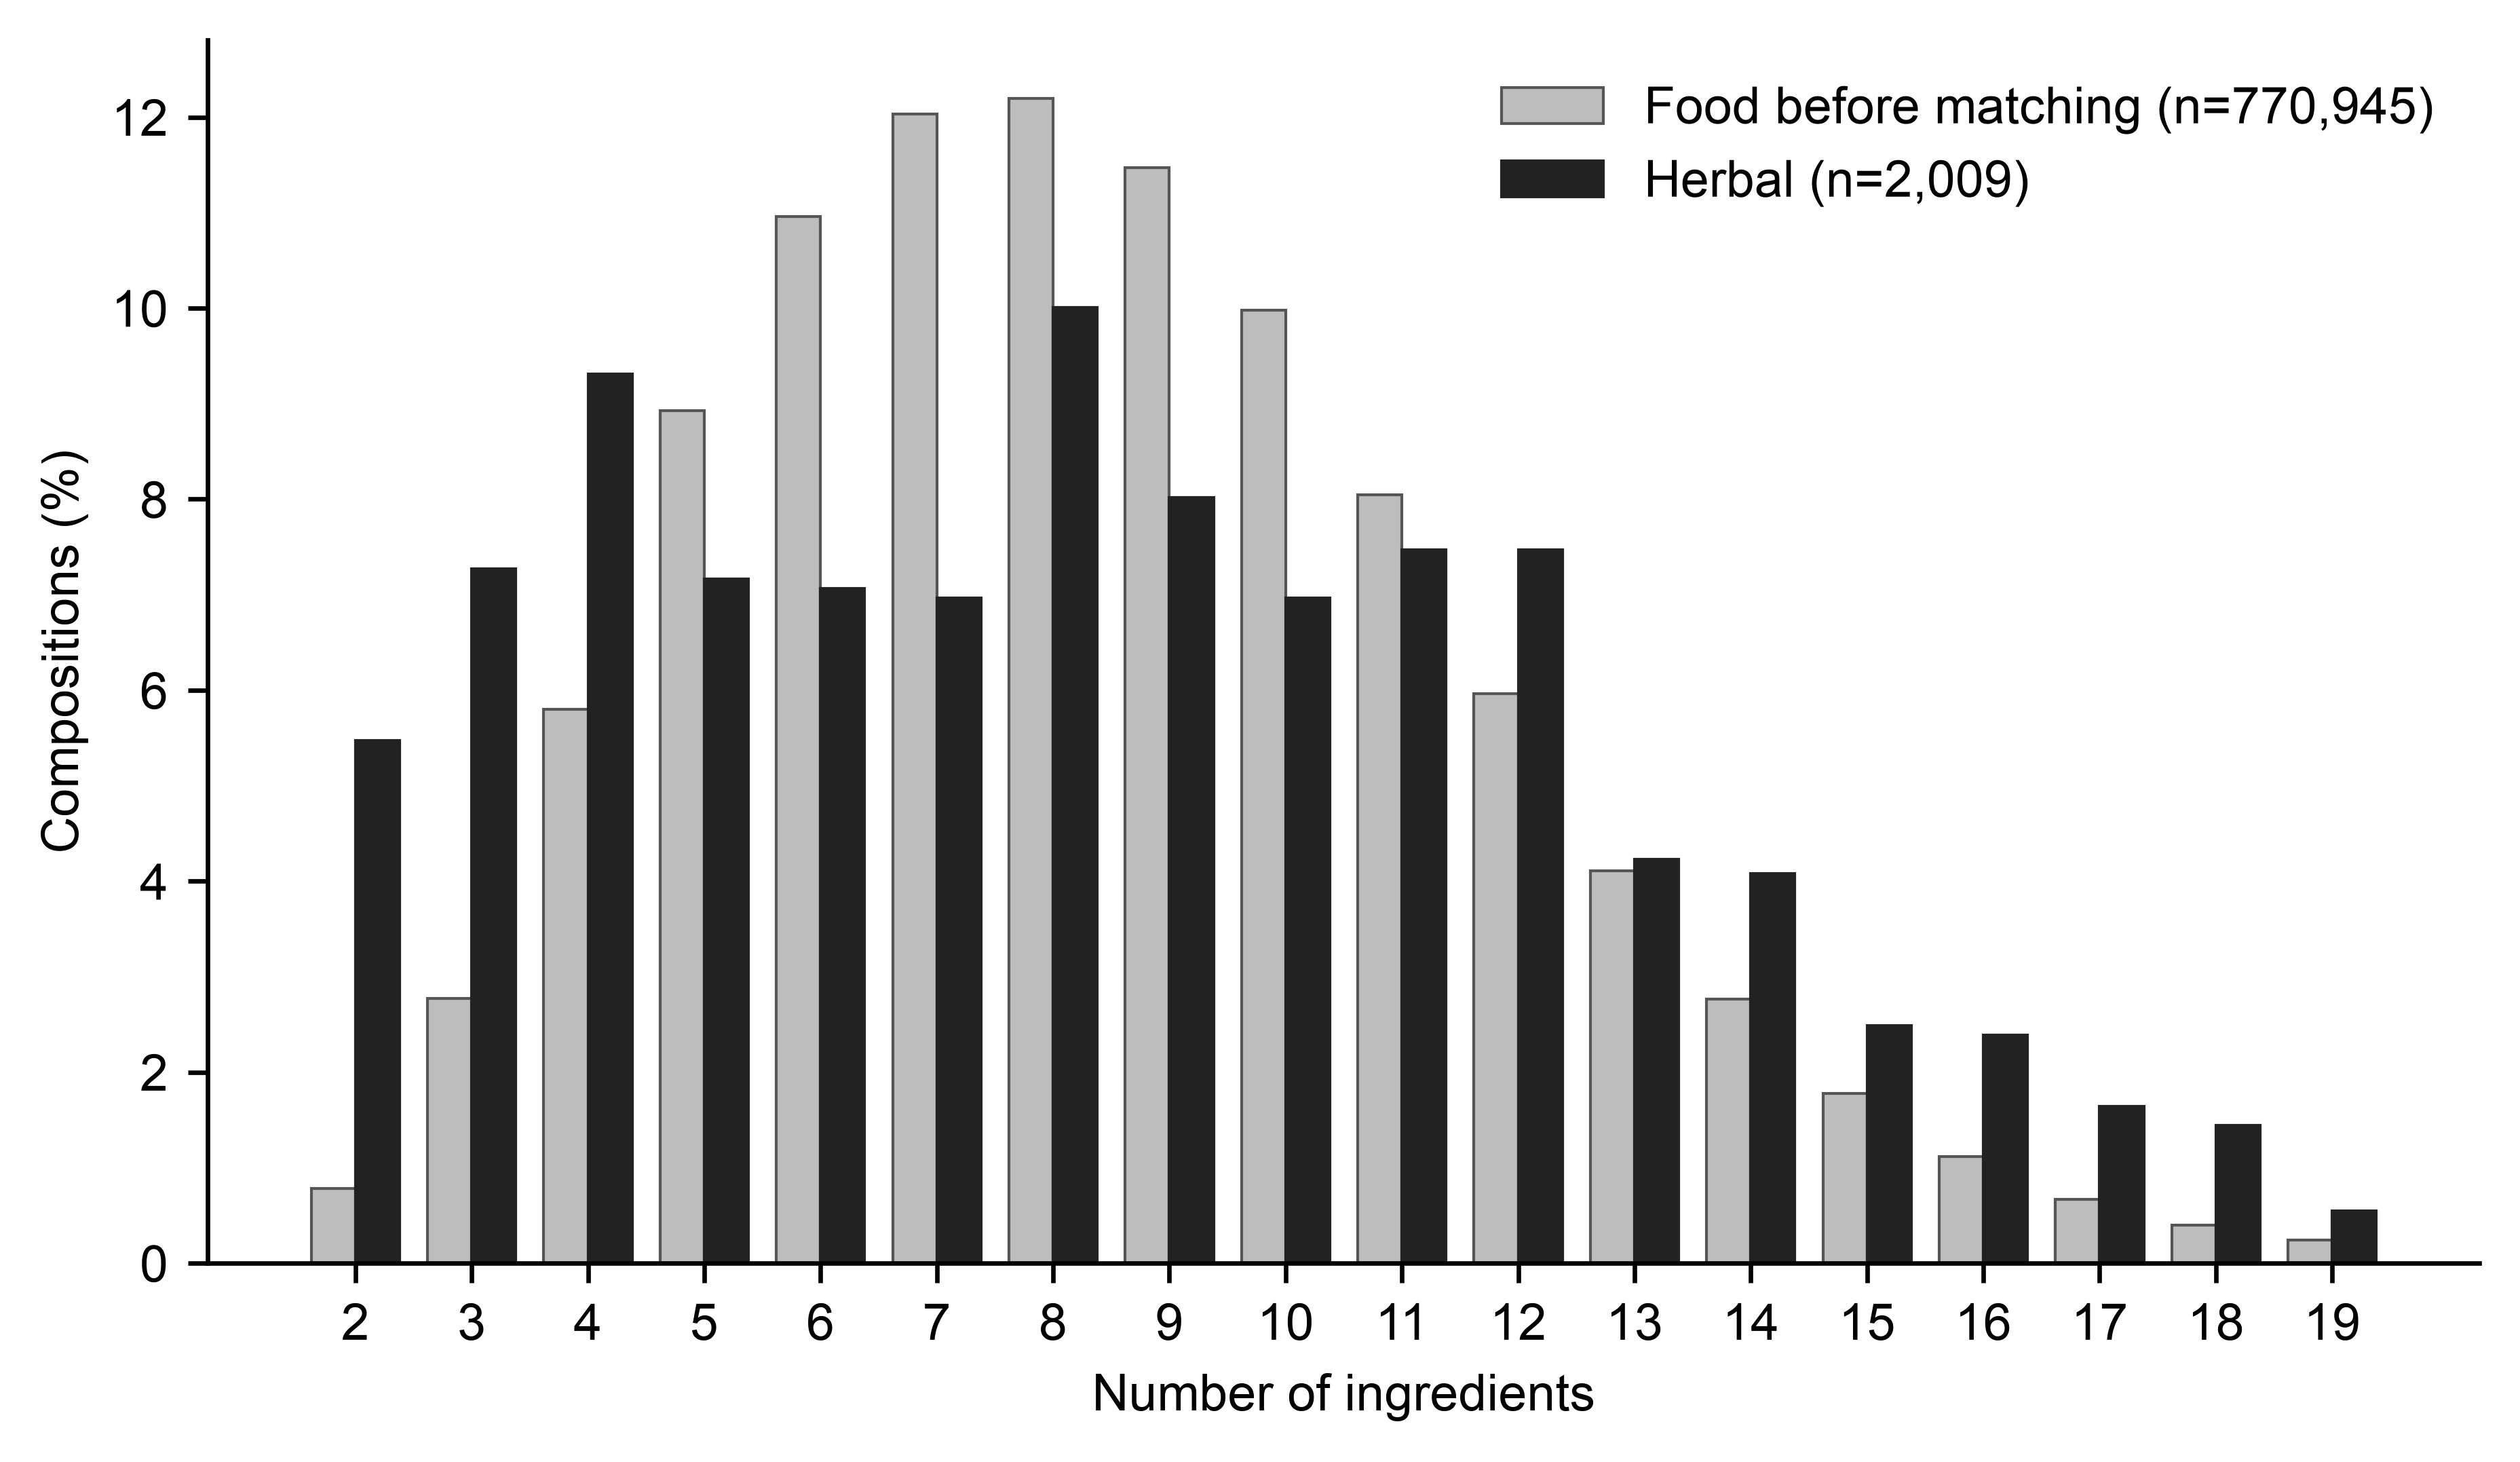

Saved: figures/Figure1_dataset_matching.png and .svg
Audit tables: work/dataset_flow.csv, work/input_manifest.json, work/food/, work/herbal/


In [6]:
assert not (fresh / "figures").exists(), "Rerun from step 2 for a fresh reproduction."
pipeline.make_figure1(checked_counts["herbal"], checked_counts["food"])
for folder in ["work", "figures"]:
    shutil.copytree(fresh / folder, repo / folder, dirs_exist_ok=True)
print("Newly generated figure:")
display(Image(filename=str(fresh / "figures/Figure1_dataset_matching.png")))
print("Saved: figures/Figure1_dataset_matching.png and .svg")
print("Audit tables: work/dataset_flow.csv, work/input_manifest.json, work/food/, work/herbal/")


<details><summary>MIT License</summary>

MIT License

Copyright (c) 2026 inseong101

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

</details>